In [6]:
import os
print("Current working directory:", os.getcwd())
print("Files in current folder:")
print(os.listdir('.'))

Current working directory: C:\Users\Ashutosh\New_Project1
Files in current folder:
['.ipynb_checkpoints', 'newproject_store.ipynb', 'Superstore sales dataset.csv']


In [7]:
import pandas as pd

# File is in the same folder as your notebook
df = pd.read_csv('Superstore sales dataset.csv')

# Save a clean version
df.to_csv('superstore_sales.csv', index=False)

print("✅ Dataset loaded successfully!")
print("Shape of the dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

✅ Dataset loaded successfully!
Shape of the dataset: (9994, 21)

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   8/11/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   8/11/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   12/6/2016   16/6/2016    Second Class    DV-13045   
3       4  US-2015-108966  11/10/2015  18/10/2015  Standard Class    SO-20335   
4       5  US-2015-108966  11/10/2015  18/10/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code

In [8]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('superstore_sales.csv')

# 1. Check problems
print(df.shape)                    # (9994, 21)
print(df.isnull().sum())           # Any missing?
print(df.duplicated().sum())       # Duplicates?

# 2. Fix dates (mixed formats)
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# 3. Clean column names (remove spaces)
df.columns = df.columns.str.replace(' ', '_').str.lower()

# 4. Drop duplicates & fill any missing profit/sales with 0
df = df.drop_duplicates()
df['profit'] = df['profit'].fillna(0)
df['sales'] = df['sales'].fillna(0)

# 5. Save cleaned version
df.to_csv('superstore_sales_cleaned.csv', index=False)
print("Cleaning done! New shape:", df.shape)

(9994, 21)
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
0
Cleaning done! New shape: (9994, 21)


            row_id                     order_date  \
count  9994.000000                           4042   
mean   4997.500000  2016-03-12 16:34:40.554180864   
min       1.000000            2014-01-02 00:00:00   
25%    2499.250000            2015-04-04 06:00:00   
50%    4997.500000            2016-05-02 00:00:00   
75%    7495.750000            2017-03-06 00:00:00   
max    9994.000000            2017-12-11 00:00:00   
std    2885.163629                            NaN   

                           ship_date   postal_code         sales     quantity  \
count                           3898   9994.000000   9994.000000  9994.000000   
mean   2016-04-08 10:07:19.610056448  55190.379428    229.858001     3.789574   
min              2014-01-04 00:00:00   1040.000000      0.444000     1.000000   
25%              2015-04-12 00:00:00  23223.000000     17.280000     2.000000   
50%              2016-06-05 12:00:00  56430.500000     54.490000     3.000000   
75%              2017-04-12 00:00:00

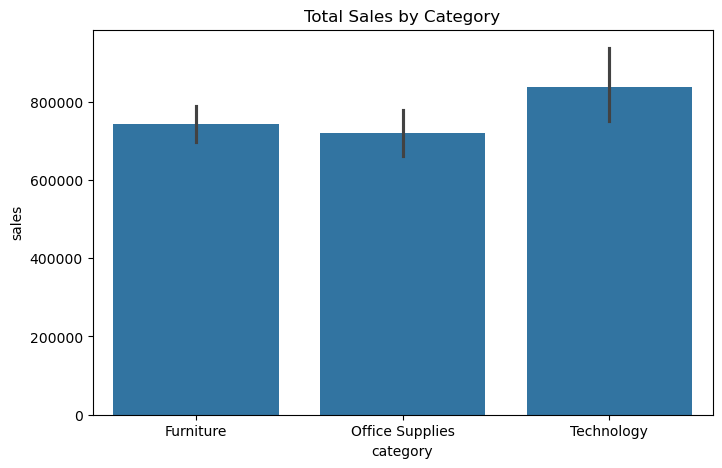

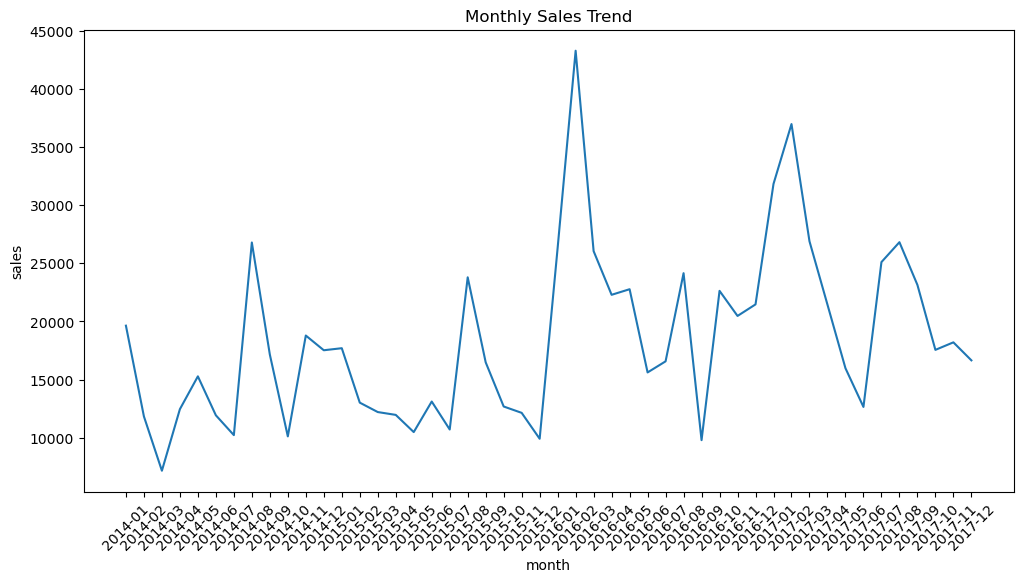

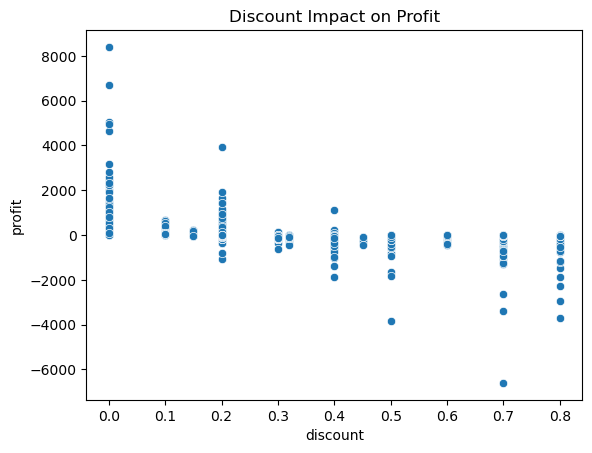

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic stats
print(df.describe())

# 1. Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='category', y='sales', estimator=sum)
plt.title('Total Sales by Category')
plt.show()

# 2. Monthly Sales Trend
df['month'] = df['order_date'].dt.to_period('M')
monthly = df.groupby('month')['sales'].sum().reset_index()
monthly['month'] = monthly['month'].astype(str)
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly, x='month', y='sales')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.show()

# 3. Profit vs Discount
sns.scatterplot(data=df, x='discount', y='profit')
plt.title('Discount Impact on Profit')
plt.show()